# Mega-benchmark : jeux DLBAC × modèles sélectionnés

Évalue et compare sur **les 11 jeux DLBAC** (synthétiques + Amazon).

**Modèles** : RuleConEx, HyConEx-Local, HyperLogic, MLP (GPU), RandomForest, DecisionTree, SVM.

## Reprise automatique
Résultats dans `results/mega_comparison/`. `RETRAIN = False` reprend les runs terminés.


In [1]:
import importlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

def find_hyconex_root() -> Path:
    candidates = [Path.cwd().resolve()]
    if candidates[0].name == "notebooks":
        candidates.append(candidates[0].parent)
    candidates.append(candidates[-1] / "HyConEx_from_scratch")
    for p in candidates:
        if (p / "mega_benchmark").is_dir():
            return p
    raise FileNotFoundError("Impossible de localiser HyConEx_from_scratch/")

ROOT = find_hyconex_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

if not torch.cuda.is_available():
    raise RuntimeError("CUDA requis pour les modèles neuronaux.")

import mega_benchmark.config as _mb_cfg
import mega_benchmark.models as _mb_models
import mega_benchmark.runner as _mb_runner

importlib.reload(_mb_cfg)
importlib.reload(_mb_models)
importlib.reload(_mb_runner)

from mega_benchmark.config import MegaBenchmarkConfig
from mega_benchmark.datasets import discover_all_dataset_ids, load_splits
from mega_benchmark.models import MODEL_LABELS, MODEL_RUNNERS
from mega_benchmark.runner import build_pivot_csv, load_summary, run_benchmark

SEED = 42
RESULTS_DIR = ROOT / "results" / "mega_comparison"
print("ROOT:", ROOT)
print("GPU:", torch.cuda.get_device_name(0))
print("Modèles disponibles:", sorted(MODEL_RUNNERS))


ROOT: D:\ecole\master 2\recherche\INN\projet\HyConEx_from_scratch
GPU: NVIDIA GeForce 940MX
Modèles disponibles: ['decision_tree', 'dlbac_alpha', 'hyconex_hyperlogic', 'hyconex_local', 'hyperlogic', 'mlp', 'rf', 'ruleconex', 'svm', 'tabresnet_dlbac']


## Configuration

In [2]:
SEED = 42
RETRAIN = False
SKIP_AMAZON = False
VERBOSE = True
FOCUS_DATASET = None  # ex. "u4k-r4k-auth11k" ou "dlbac/amazon1"

SOURCES = ["dlbac"]
MODELS = [
    "ruleconex",
    "hyconex_local",
    "hyperlogic",
    "mlp",
    "rf",
    "decision_tree",
    "svm",
]

FAST_MODE = False
RESULTS_DIR = ROOT / "results" / "mega_comparison"

cfg = MegaBenchmarkConfig(
    seed=SEED,
    retrain=RETRAIN,
    skip_amazon=SKIP_AMAZON,
    verbose=VERBOSE,
    results_dir="results/mega_comparison",
    dataset_sources=SOURCES,
    models=MODELS,
    focus_dataset=FOCUS_DATASET,
    neural_epochs_dlbac=15 if FAST_MODE else 25,
    neural_epochs_amazon=10 if FAST_MODE else 15,
    neural_epochs_tabular=20 if FAST_MODE else 30,
    sklearn_fast=FAST_MODE,
    use_gpu_mlp=True,
)

all_ids = discover_all_dataset_ids(sources=SOURCES, skip_amazon=SKIP_AMAZON)
if FOCUS_DATASET:
    all_ids = [d for d in all_ids if d == FOCUS_DATASET or d.endswith(str(FOCUS_DATASET))]

unknown_models = [m for m in MODELS if m not in MODEL_RUNNERS]
if unknown_models:
    raise ValueError(f"Modèles invalides: {unknown_models}. Disponibles: {sorted(MODEL_RUNNERS)}")

n_runs = len(all_ids) * len(MODELS)
print(f"Jeux découverts : {len(all_ids)}")
print(f"Modèles         : {len(MODELS)}")
print(f"Runs totaux     : {n_runs}")
print(f"Résultats       : {RESULTS_DIR}")


Jeux découverts : 11
Modèles         : 7
Runs totaux     : 77
Résultats       : D:\ecole\master 2\recherche\INN\projet\HyConEx_from_scratch\results\mega_comparison


## Inventaire des jeux

In [3]:
inv = []
for did in all_ids:
    try:
        s = load_splits(did, seed=SEED)
        inv.append({
            "dataset_id": did,
            "source": s.source,
            "n_train": len(s.y_train),
            "n_val": len(s.y_val),
            "n_test": len(s.y_test),
            "n_features": s.num_features,
            "n_classes": s.num_classes,
        })
    except Exception as exc:
        inv.append({"dataset_id": did, "error": str(exc)})

df_inv = pd.DataFrame(inv)
display(df_inv)
print("Par source :")
print(df_inv.groupby("source").size() if "source" in df_inv.columns else "—")

,dataset_id,source,n_train,n_val,n_test,n_features,n_classes
0,dlbac/amazon1,dlbac,20972,5244,6553,14419,2
1,dlbac/amazon2,dlbac,20972,5244,6553,9476,2
2,dlbac/amazon3,dlbac,20972,5244,6553,9124,2
3,dlbac/u4k-r4k-auth11k,dlbac,7017,1755,2192,157,16
4,dlbac/u4k-r4k-auth21k,dlbac,13427,3357,4195,146,16
5,dlbac/u4k-r4k-auth22k,dlbac,14453,3614,4516,133,16
6,dlbac/u4k-r6k-auth28k,dlbac,18400,4601,5750,145,16
7,dlbac/u4k-r7k-auth20k,dlbac,12821,3206,4006,152,16
8,dlbac/u5k-r5k-auth12k,dlbac,8121,2031,2538,170,16
9,dlbac/u5k-r5k-auth19k,dlbac,12502,3126,3907,164,16


Par source :
source
dlbac    11
dtype: int64


## État de reprise (progress.json)

In [4]:
progress_path = RESULTS_DIR / "progress.json"
if progress_path.is_file():
    prog = json.loads(progress_path.read_text(encoding="utf-8"))
    done = len(prog.get("completed", []))
    print(f"Runs terminés (checkpoint) : {done} / {n_runs}")
    print(f"Dernière MAJ : {prog.get('updated_at', '—')}")
    if done and not RETRAIN:
        print("→ Les runs déjà terminés seront chargés depuis le cache.")
else:
    print("Aucun checkpoint — démarrage à zéro.")

Runs terminés (checkpoint) : 234 / 77
Dernière MAJ : 2026-06-25T05:56:52.139232+00:00
→ Les runs déjà terminés seront chargés depuis le cache.


## Lancer le benchmark

**Cellule longue** — peut prendre plusieurs heures sur tous les jeux. Interrompre (Kernel → Interrupt) est sans risque : relancez cette cellule.

In [5]:
rows = run_benchmark(cfg)
n_ok = sum(1 for r in rows if r.get("status") == "ok")
n_skip = sum(1 for r in rows if r.get("status") == "skipped")
n_err = sum(1 for r in rows if r.get("status") == "error")
n_cache = sum(1 for r in rows if r.get("_from_cache"))
print(f"Terminé — ok={n_ok} skipped={n_skip} err={n_err} (dont cache={n_cache})")

[cache 1/77] dlbac/amazon1 | ruleconex
[cache 2/77] dlbac/amazon1 | hyconex_local
[cache 3/77] dlbac/amazon1 | hyperlogic
[cache 4/77] dlbac/amazon1 | mlp
[cache 5/77] dlbac/amazon1 | rf
[cache 6/77] dlbac/amazon1 | decision_tree
[cache 7/77] dlbac/amazon1 | svm
[cache 8/77] dlbac/amazon2 | ruleconex
[cache 9/77] dlbac/amazon2 | hyconex_local
[cache 10/77] dlbac/amazon2 | hyperlogic
[cache 11/77] dlbac/amazon2 | mlp
[cache 12/77] dlbac/amazon2 | rf
[cache 13/77] dlbac/amazon2 | decision_tree
[cache 14/77] dlbac/amazon2 | svm
[cache 15/77] dlbac/amazon3 | ruleconex
[cache 16/77] dlbac/amazon3 | hyconex_local
[cache 17/77] dlbac/amazon3 | hyperlogic
[cache 18/77] dlbac/amazon3 | mlp
[cache 19/77] dlbac/amazon3 | rf
[cache 20/77] dlbac/amazon3 | decision_tree
[cache 21/77] dlbac/amazon3 | svm
[cache 22/77] dlbac/u4k-r4k-auth11k | ruleconex
[cache 23/77] dlbac/u4k-r4k-auth11k | hyconex_local
[cache 24/77] dlbac/u4k-r4k-auth11k | hyperlogic
[cache 25/77] dlbac/u4k-r4k-auth11k | mlp
[cache 2

## Tableaux de résultats

In [6]:
rows = load_summary(RESULTS_DIR)
df = pd.DataFrame(rows)
df_ok = df[df["status"] == "ok"].copy()

pivot_acc = df_ok.pivot_table(index="dataset_id", columns="model_label", values="accuracy", aggfunc="first")
pivot_f1 = df_ok.pivot_table(index="dataset_id", columns="model_label", values="f1_macro", aggfunc="first")
pivot_auc = df_ok.pivot_table(index="dataset_id", columns="model_label", values="auc", aggfunc="first")

print("=== Accuracy ===")
display(pivot_acc.round(4))
print("=== F1 macro ===")
display(pivot_f1.round(4))

=== Accuracy ===


model_label,DecisionTree,HyConEx-Local,HyperLogic,MLP,RandomForest,RuleConEx,SVM
dataset_id,,,,,,,
dlbac/amazon1,0.9417,0.9437,0.9408,0.9388,0.9408,0.9409,0.9440
dlbac/amazon2,0.9454,0.9463,0.9438,0.9380,0.9438,0.9422,0.9443
dlbac/amazon3,0.9437,0.9454,0.9425,0.9382,0.9425,0.9348,0.9432
dlbac/u4k-r4k-auth11k,0.4270,0.9722,0.9749,0.9754,0.9156,0.9758,0.9740
dlbac/u4k-r4k-auth21k,0.5142,0.8791,0.8641,0.8963,0.6985,0.8944,0.8157
dlbac/u4k-r4k-auth22k,0.4703,0.7170,0.6685,0.7307,0.5999,0.7033,0.6678
dlbac/u4k-r6k-auth28k,0.4873,0.8157,0.8315,0.8494,0.6873,0.8329,0.7325
dlbac/u4k-r7k-auth20k,0.4423,0.8779,0.8757,0.8857,0.7718,0.8849,0.8572
dlbac/u5k-r5k-auth12k,0.4098,0.9925,0.9929,0.9945,0.9571,0.9937,0.9913


=== F1 macro ===


model_label,DecisionTree,HyConEx-Local,HyperLogic,MLP,RandomForest,RuleConEx,SVM
dataset_id,,,,,,,
dlbac/amazon1,0.5586,0.6285,0.4847,0.6920,0.4847,0.7084,0.5558
dlbac/amazon2,0.5827,0.6269,0.4856,0.6851,0.4856,0.6685,0.5016
dlbac/amazon3,0.5493,0.6626,0.4852,0.6810,0.4852,0.6850,0.4985
dlbac/u4k-r4k-auth11k,0.3853,0.9710,0.9737,0.9759,0.9125,0.9752,0.9749
dlbac/u4k-r4k-auth21k,0.3494,0.8736,0.8641,0.8914,0.5866,0.8906,0.8277
dlbac/u4k-r4k-auth22k,0.3605,0.6778,0.6981,0.7070,0.4394,0.6800,0.6379
dlbac/u4k-r6k-auth28k,0.4296,0.8409,0.8556,0.8692,0.6974,0.8519,0.7827
dlbac/u4k-r7k-auth20k,0.3346,0.9048,0.9000,0.9072,0.7293,0.9067,0.8913
dlbac/u5k-r5k-auth12k,0.4614,0.9932,0.9930,0.9949,0.9551,0.9940,0.9935


In [7]:
if "cf_validity" in df_ok.columns and df_ok["cf_validity"].notna().any():
    pivot_cf = df_ok.pivot_table(index="dataset_id", columns="model_label", values="cf_validity", aggfunc="first")
    print("=== Validité contrefactuelle (RuleConEx) ===")
    display(pivot_cf.round(4))

if "elapsed_sec" in df_ok.columns:
    pivot_time = df_ok.pivot_table(index="dataset_id", columns="model_label", values="elapsed_sec", aggfunc="first")
    print("=== Temps (s) ===")
    display(pivot_time.round(1))

=== Validité contrefactuelle (RuleConEx) ===


model_label,RuleConEx
dataset_id,
dlbac/amazon1,1.0000
dlbac/amazon2,1.0000
dlbac/amazon3,1.0000
dlbac/u4k-r4k-auth11k,0.9573
dlbac/u4k-r4k-auth21k,0.9844
dlbac/u4k-r4k-auth22k,0.9969
dlbac/u4k-r6k-auth28k,0.9885
dlbac/u4k-r7k-auth20k,0.9896
dlbac/u5k-r5k-auth12k,0.9552


=== Temps (s) ===


model_label,DecisionTree,HyConEx-Local,HyperLogic,MLP,RandomForest,RuleConEx,SVM
dataset_id,,,,,,,
dlbac/amazon1,166.1,549.6,460.3,124.3,39.4,934.8,12.4
dlbac/amazon2,95.0,383.1,430.2,82.6,27.8,762.2,8.8
dlbac/amazon3,61.8,380.6,430.6,81.7,16.7,734.9,7.7
dlbac/u4k-r4k-auth11k,0.2,19.2,83.8,10.2,0.7,498.3,0.7
dlbac/u4k-r4k-auth21k,0.5,32.9,154.8,14.6,1.1,903.9,1.6
dlbac/u4k-r4k-auth22k,0.5,89.4,183.4,16.6,1.0,877.2,1.8
dlbac/u4k-r6k-auth28k,0.5,42.5,206.4,19.4,1.7,1246.1,2.2
dlbac/u4k-r7k-auth20k,0.6,30.3,145.6,13.9,1.0,879.7,1.2
dlbac/u5k-r5k-auth12k,0.2,21.3,99.8,9.4,0.6,606.8,0.6


## Heatmaps

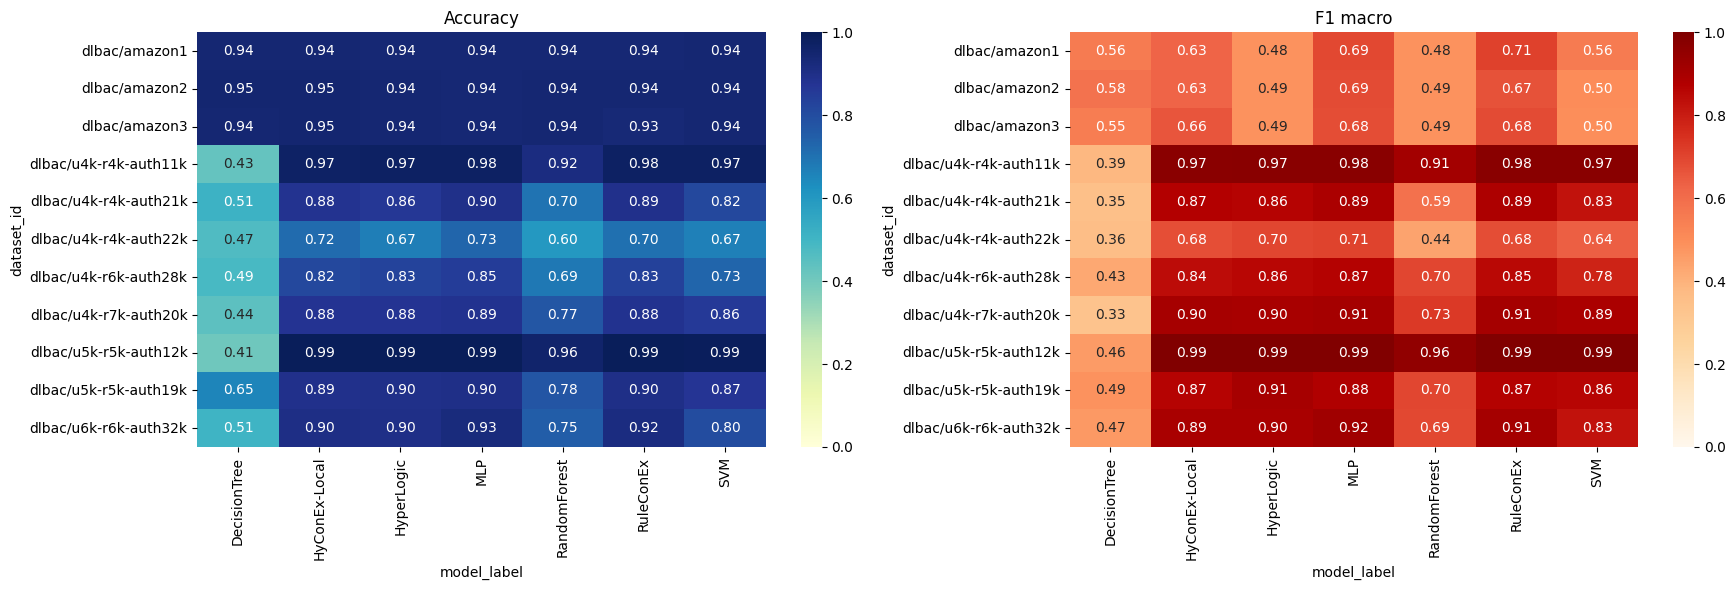

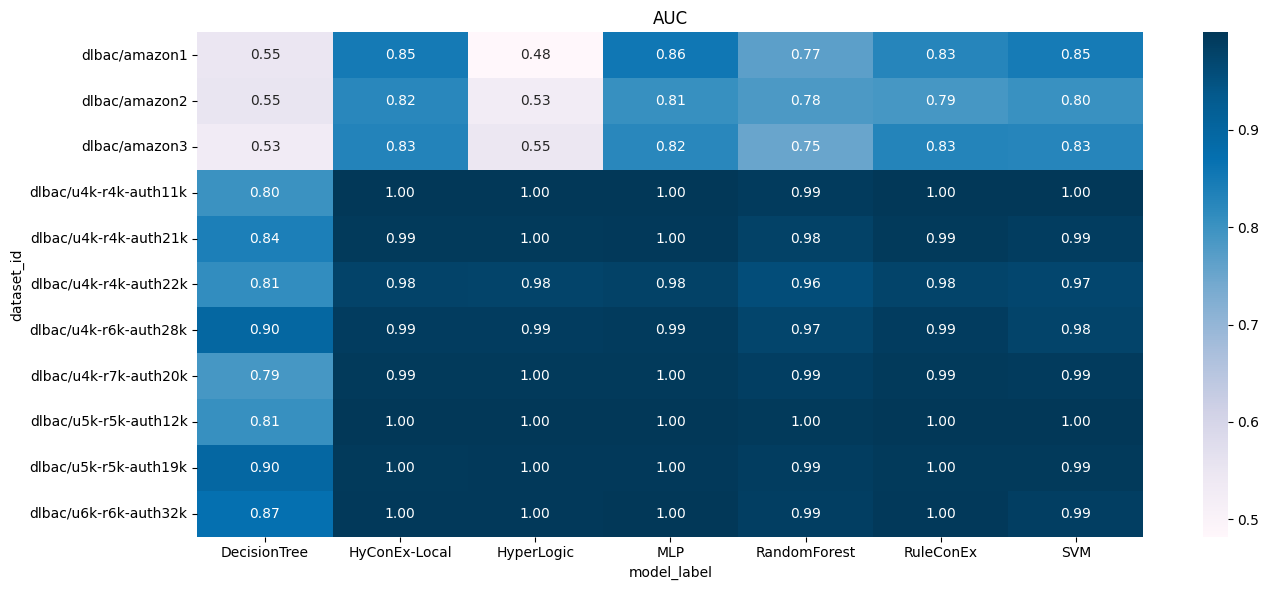

In [8]:
if not df_ok.empty:
    fig_h = max(6, len(pivot_acc) * 0.4)
    fig, axes = plt.subplots(1, 2, figsize=(18, fig_h))
    sns.heatmap(pivot_acc.astype(float), annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[0], vmin=0, vmax=1)
    axes[0].set_title("Accuracy")
    sns.heatmap(pivot_f1.astype(float), annot=True, fmt=".2f", cmap="OrRd", ax=axes[1], vmin=0, vmax=1)
    axes[1].set_title("F1 macro")
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / "heatmap_accuracy_f1.png", dpi=140, bbox_inches="tight")
    plt.show()

    if pivot_auc.notna().any().any():
        fig2, ax2 = plt.subplots(figsize=(14, fig_h))
        sns.heatmap(pivot_auc.astype(float), annot=True, fmt=".2f", cmap="PuBu", ax=ax2)
        ax2.set_title("AUC")
        plt.tight_layout()
        fig2.savefig(RESULTS_DIR / "heatmap_auc.png", dpi=140, bbox_inches="tight")
        plt.show()

## Classement global (accuracy)


In [9]:
if not df_ok.empty:
    rank_acc = df_ok.groupby("model_label").agg(
        mean=("accuracy", "mean"), std=("accuracy", "std"), n=("accuracy", "count")
    ).sort_values("mean", ascending=False)
    rank_acc["rank"] = range(1, len(rank_acc) + 1)
    display(rank_acc.round(4))
    winners_acc = pivot_acc.idxmax(axis=1).value_counts().sort_values(ascending=False)
    print("Victoires (accuracy par jeu) :")
    display(winners_acc)


,mean,std,n,rank
model_label,,,,
MLP,0.9066,0.0711,11,1
RuleConEx,0.9016,0.0793,11,2
HyConEx-Local,0.8987,0.0784,11,3
HyperLogic,0.8940,0.0891,11,4
SVM,0.8675,0.1046,11,5
RandomForest,0.8167,0.1275,11,6
DecisionTree,0.6129,0.2217,11,7


Victoires (accuracy par jeu) :


MLP              7
HyConEx-Local    2
SVM              1
RuleConEx        1
Name: count, dtype: int64

## Classements et graphiques par métrique

Accuracy, F1 macro, AUC, validité CF, binary accuracy (si dispo), temps (plus bas = mieux).


In [10]:
METRIC_SPECS = [
    ("accuracy", "Accuracy", True),
    ("f1_macro", "F1 macro", True),
    ("auc", "AUC", True),
    ("cf_validity", "Validité CF", True),
    ("binary_accuracy", "Binary accuracy", True),
    ("elapsed_sec", "Temps (s)", False),
]

def build_metric_ranking(frame, metric, higher_is_better=True):
    if metric not in frame.columns:
        return None
    sub = frame[frame[metric].notna()].copy()
    if sub.empty:
        return None
    rank = sub.groupby("model_label").agg(
        mean=(metric, "mean"),
        std=(metric, "std"),
        median=(metric, "median"),
        min=(metric, "min"),
        max=(metric, "max"),
        n=(metric, "count"),
    )
    return rank.sort_values("mean", ascending=not higher_is_better)

rankings_by_metric = {}
summary_parts = []
pivot_by_metric = {}

if not df_ok.empty:
    for metric, label, higher in METRIC_SPECS:
        rank_m = build_metric_ranking(df_ok, metric, higher)
        if rank_m is None:
            print(f"{label} : pas de données")
            continue
        rankings_by_metric[metric] = rank_m
        pivot_by_metric[metric] = df_ok.pivot_table(
            index="dataset_id", columns="model_label", values=metric, aggfunc="first"
        )
        print(f"=== Classement — {label} ===")
        out = rank_m.copy()
        out["rank"] = range(1, len(out) + 1)
        display(out.round(4))
        part = out.reset_index()
        part.insert(0, "metric", label)
        summary_parts.append(part)

    if summary_parts:
        rankings_all = pd.concat(summary_parts, ignore_index=True)
        cols = ["metric", "model_label", "rank", "mean", "std", "median", "min", "max", "n"]
        rankings_all[cols].to_csv(RESULTS_DIR / "rankings_all_metrics.csv", index=False)
        print("Export : rankings_all_metrics.csv")


=== Classement — Accuracy ===


,mean,std,median,min,max,n,rank
model_label,,,,,,,
MLP,0.9066,0.0711,0.9252,0.7307,0.9945,11,1
RuleConEx,0.9016,0.0793,0.9160,0.7033,0.9937,11,2
HyConEx-Local,0.8987,0.0784,0.9026,0.7170,0.9925,11,3
HyperLogic,0.8940,0.0891,0.9014,0.6685,0.9929,11,4
SVM,0.8675,0.1046,0.8715,0.6678,0.9913,11,5
RandomForest,0.8167,0.1275,0.7753,0.5999,0.9571,11,6
DecisionTree,0.6129,0.2217,0.5068,0.4098,0.9454,11,7


=== Classement — F1 macro ===


,mean,std,median,min,max,n,rank
model_label,,,,,,,
MLP,0.8365,0.1212,0.8790,0.6810,0.9949,11,1
RuleConEx,0.8305,0.1224,0.8684,0.6685,0.9940,11,2
HyConEx-Local,0.8128,0.1376,0.8664,0.6269,0.9932,11,3
HyperLogic,0.7766,0.2017,0.8641,0.4847,0.9930,11,4
SVM,0.7593,0.1816,0.8259,0.4985,0.9935,11,5
RandomForest,0.6516,0.1745,0.6937,0.4394,0.9551,11,6
DecisionTree,0.4514,0.0878,0.4614,0.3346,0.5827,11,7


=== Classement — AUC ===


...

=== Classement — Validité CF ===


,mean,std,median,min,max,n,rank
model_label,,,,,,,
RuleConEx,0.9874,0.0163,0.9906,0.9552,1.0,11,1


Binary accuracy : pas de données
=== Classement — Temps (s) ===


,mean,std,median,min,max,n,rank
model_label,,,,,,,
SVM,3.6471,4.0317,1.8403,0.6017,12.3554,11,1
RandomForest,8.4340,13.5493,1.0756,0.6207,39.3867,11,2
DecisionTree,29.6271,55.4595,0.4719,0.1670,166.0571,11,3
MLP,36.8448,39.7818,16.6393,9.3562,124.3429,11,4
HyConEx-Local,148.3122,191.8583,42.4932,19.2076,549.6115,11,5
HyperLogic,234.4291,139.2025,183.4250,83.8055,460.2682,11,6
RuleConEx,891.6228,270.3271,879.7123,498.3042,1462.1713,11,7


Export : rankings_all_metrics.csv


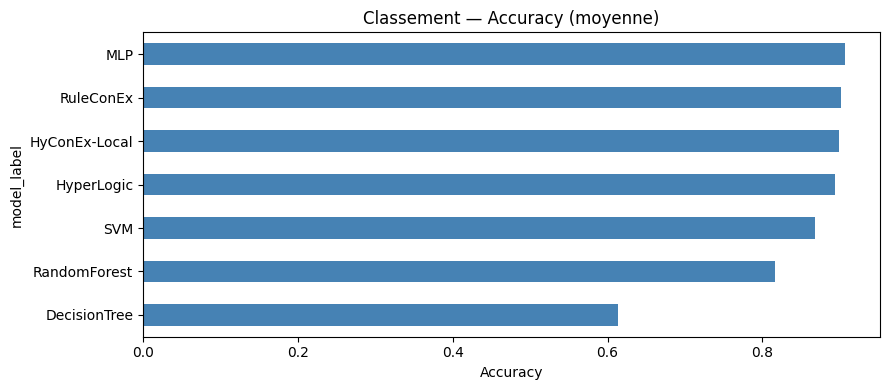

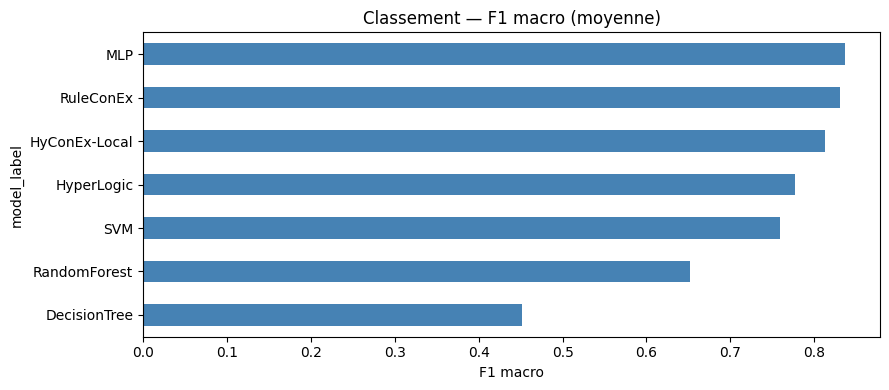

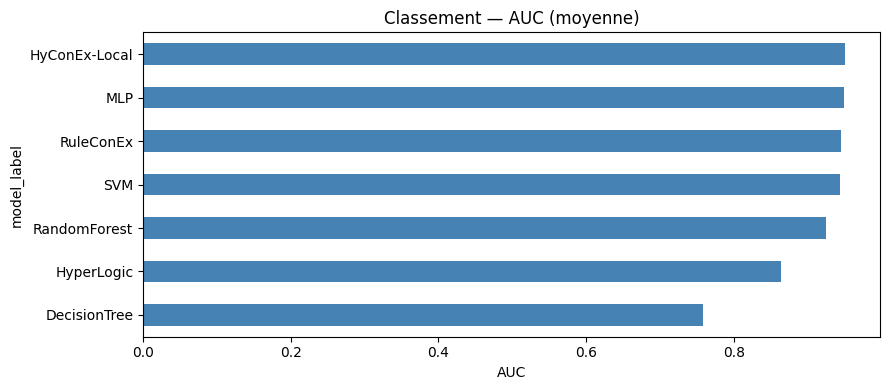

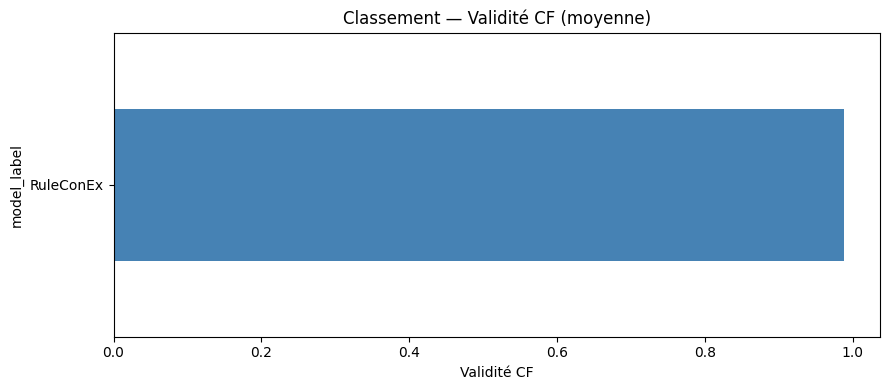

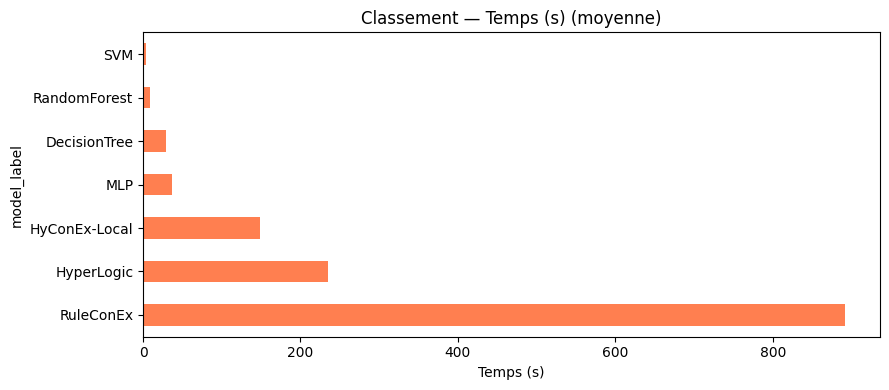

In [11]:
if rankings_by_metric:
    # Barres horizontales — une figure par métrique
    for metric, label, higher in METRIC_SPECS:
        if metric not in rankings_by_metric:
            continue
        series = rankings_by_metric[metric]["mean"].sort_values(ascending=higher)
        fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(series))))
        color = "coral" if metric == "elapsed_sec" else "steelblue"
        series.plot(kind="barh", ax=ax, color=color)
        ax.set_title(f"Classement — {label} (moyenne)")
        ax.set_xlabel(label)
        plt.tight_layout()
        safe = metric.replace(" ", "_")
        fig.savefig(RESULTS_DIR / f"ranking_{safe}.png", dpi=140, bbox_inches="tight")
        plt.show()


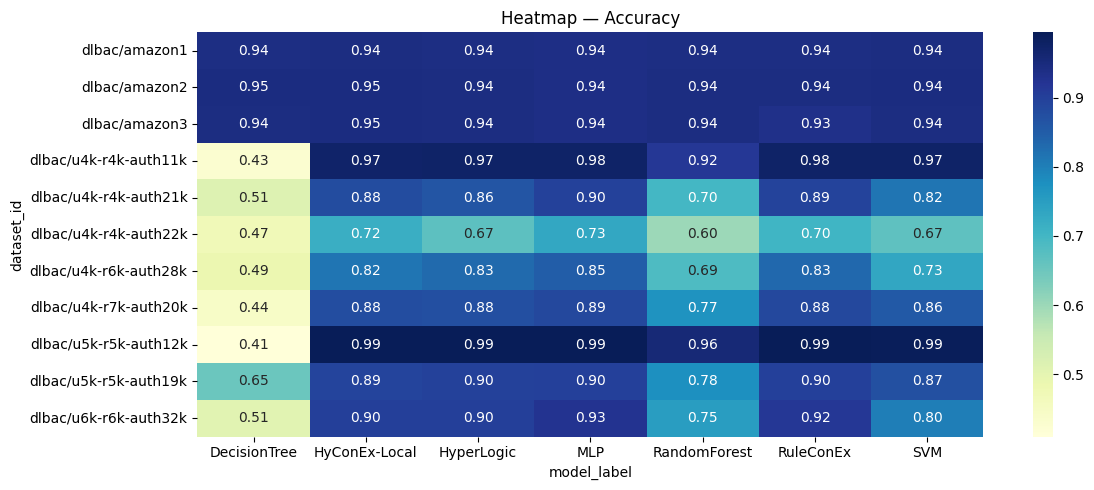

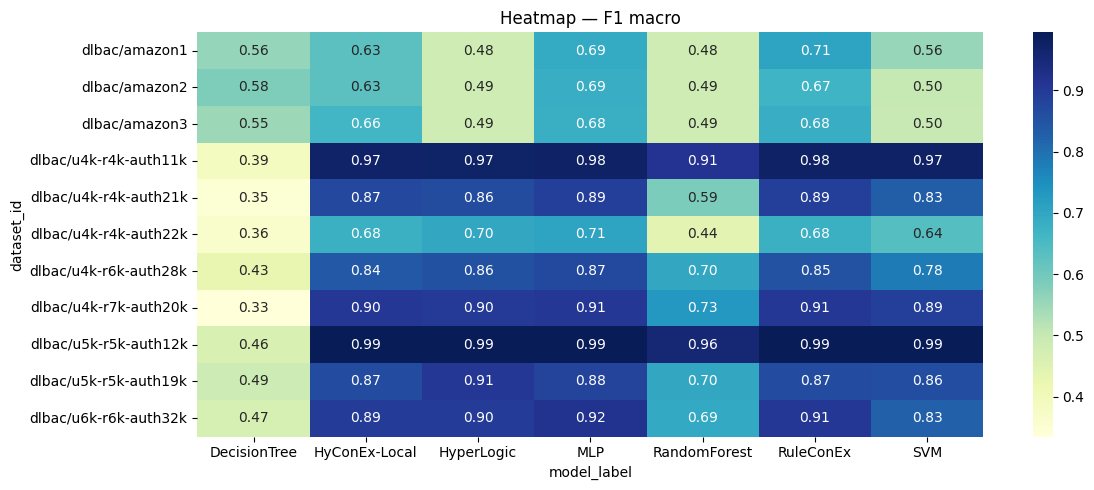

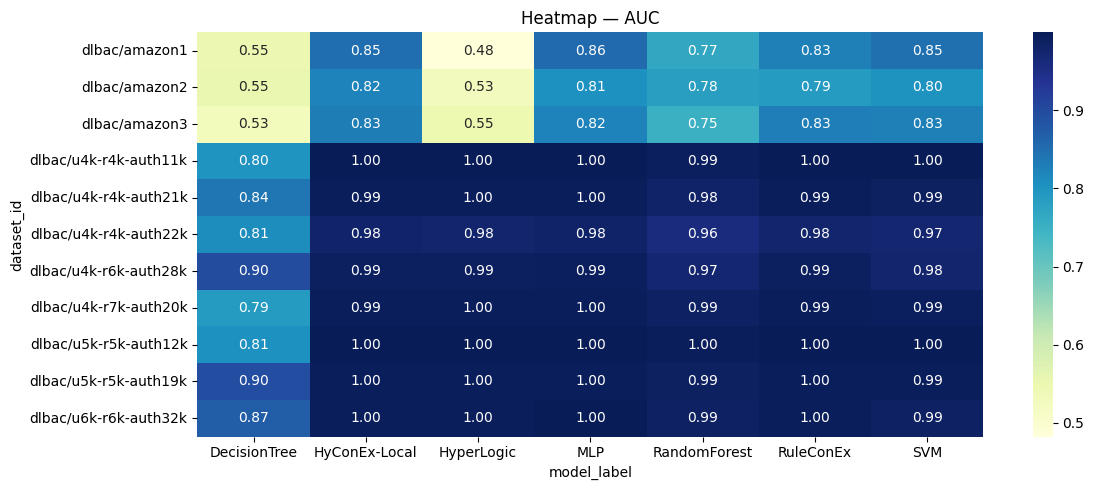

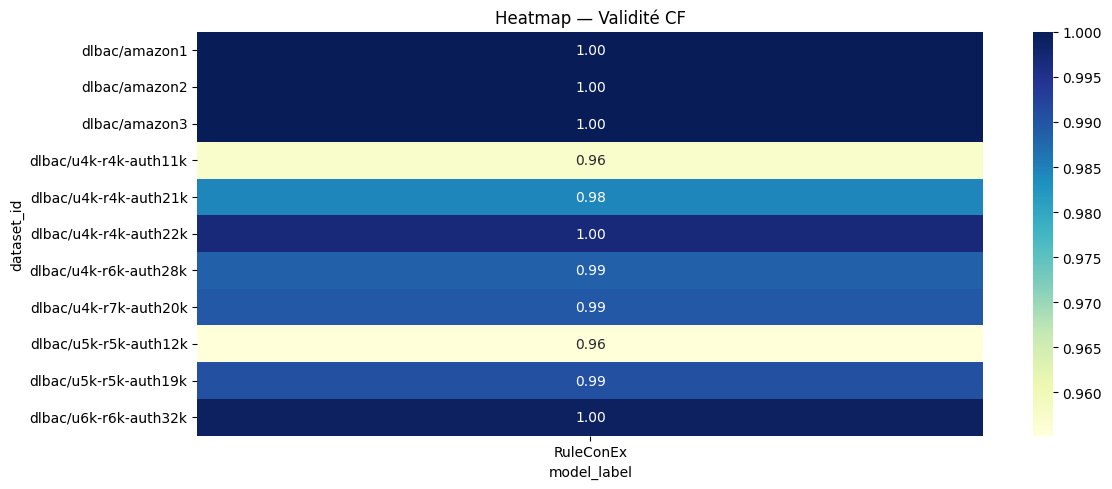

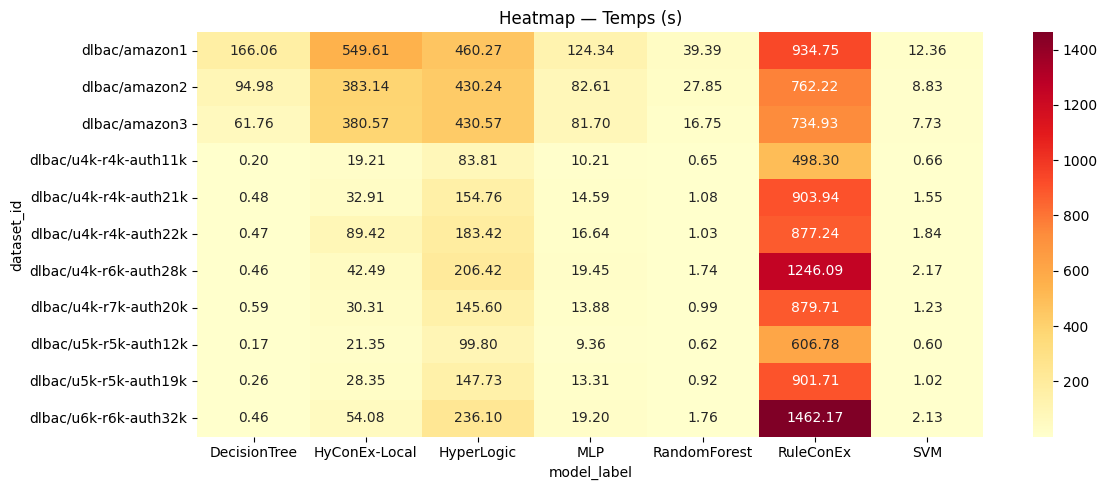

In [12]:
if pivot_by_metric:
    # Heatmaps par métrique
    for metric, label, higher in METRIC_SPECS:
        pv = pivot_by_metric.get(metric)
        if pv is None or pv.empty:
            continue
        fig_h = max(5, len(pv) * 0.45)
        fig, ax = plt.subplots(figsize=(12, fig_h))
        sns.heatmap(pv.astype(float), annot=True, fmt=".2f", cmap="YlGnBu" if higher else "YlOrRd", ax=ax)
        ax.set_title(f"Heatmap — {label}")
        plt.tight_layout()
        safe = metric.replace(" ", "_")
        fig.savefig(RESULTS_DIR / f"heatmap_{safe}.png", dpi=140, bbox_inches="tight")
        plt.show()


Victoires — accuracy


MLP              7
HyConEx-Local    2
SVM              1
RuleConEx        1
Name: count, dtype: int64

Victoires — f1_macro


MLP           8
RuleConEx     2
HyperLogic    1
Name: count, dtype: int64

Victoires — auc


...

Victoires — cf_validity


RuleConEx    11
Name: count, dtype: int64

Victoires — elapsed_sec


DecisionTree    8
SVM             3
Name: count, dtype: int64

metric,accuracy,auc,cf_validity,elapsed_sec,f1_macro
model_label,,,,,
DecisionTree,0.0,0.0,0.0,8.0,0.0
HyConEx-Local,2.0,2.0,0.0,0.0,0.0
HyperLogic,0.0,1.0,0.0,0.0,1.0
MLP,7.0,7.0,0.0,0.0,8.0
RuleConEx,1.0,1.0,11.0,0.0,2.0
SVM,1.0,0.0,0.0,3.0,0.0


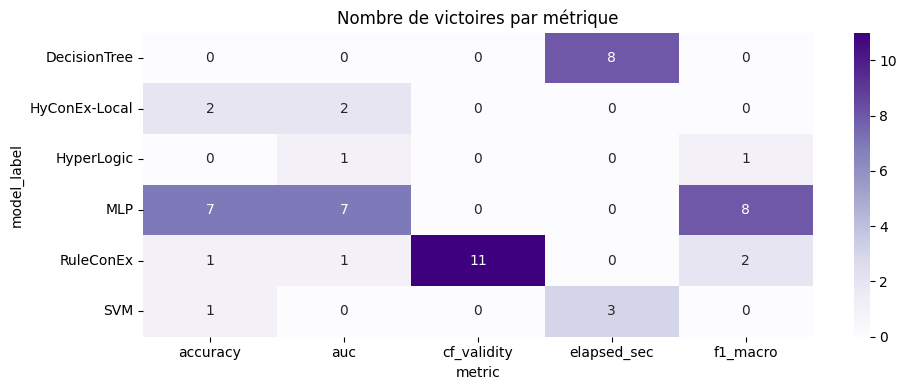

In [13]:
if pivot_by_metric:
    # Victoires par métrique (meilleur score par jeu)
    win_rows = []
    for metric, pv in pivot_by_metric.items():
        numeric = pv.astype(float)
        if metric == "elapsed_sec":
            best = numeric.idxmin(axis=1)
        else:
            best = numeric.idxmax(axis=1)
        counts = best.value_counts().sort_values(ascending=False)
        print(f"Victoires — {metric}")
        display(counts)
        for model_label, n_wins in counts.items():
            win_rows.append({"metric": metric, "model_label": model_label, "n_wins": int(n_wins)})
    if win_rows:
        wins_df = pd.DataFrame(win_rows)
        wins_pivot = wins_df.pivot_table(index="model_label", columns="metric", values="n_wins", fill_value=0)
        display(wins_pivot)
        wins_pivot.to_csv(RESULTS_DIR / "wins_by_metric.csv")
        fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * len(wins_pivot))))
        sns.heatmap(wins_pivot, annot=True, fmt=".0f", cmap="Purples", ax=ax)
        ax.set_title("Nombre de victoires par métrique")
        plt.tight_layout()
        fig.savefig(RESULTS_DIR / "wins_by_metric.png", dpi=140, bbox_inches="tight")
        plt.show()


=== Rang moyen (1 = meilleur) ===


,accuracy,f1_macro,auc,cf_validity,elapsed_sec,rang_moyen
model_label,,,,,,
MLP,1.0,1.0,2.0,NaN,4.0,2.00
RuleConEx,2.0,2.0,3.0,1.0,7.0,3.00
HyConEx-Local,3.0,3.0,1.0,NaN,5.0,3.00
SVM,5.0,5.0,4.0,NaN,1.0,3.75
RandomForest,6.0,6.0,5.0,NaN,2.0,4.75
HyperLogic,4.0,4.0,6.0,NaN,6.0,5.00
DecisionTree,7.0,7.0,7.0,NaN,3.0,6.00


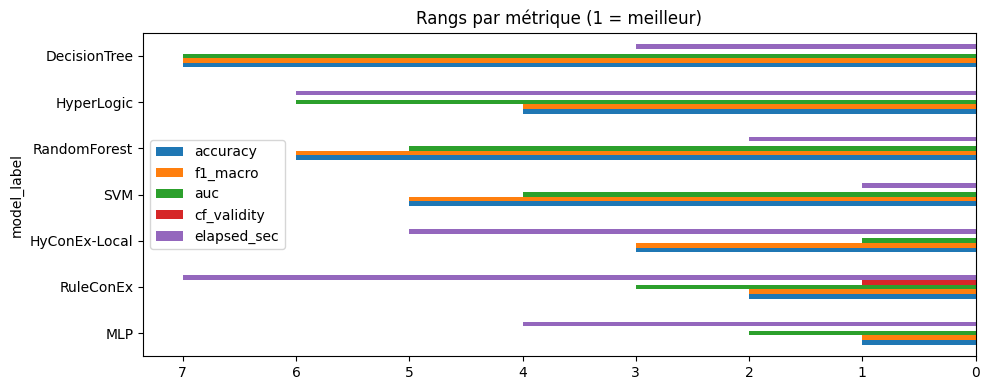

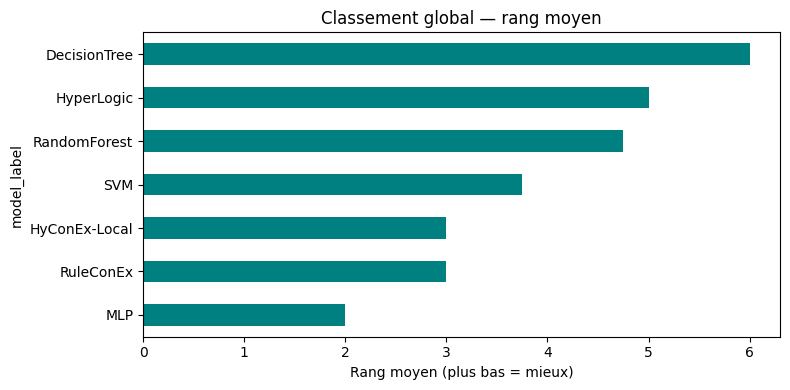

In [14]:
if rankings_by_metric:
    # Synthèse multi-métriques (rang moyen)
    rank_frames = []
    for metric, label, higher in METRIC_SPECS:
        if metric not in rankings_by_metric:
            continue
        r = rankings_by_metric[metric]["mean"].rank(ascending=not higher, method="average")
        rank_frames.append(r.rename(metric))
    if rank_frames:
        rank_matrix = pd.concat(rank_frames, axis=1)
        rank_matrix["rang_moyen"] = rank_matrix.mean(axis=1)
        rank_matrix = rank_matrix.sort_values("rang_moyen")
        print("=== Rang moyen (1 = meilleur) ===")
        display(rank_matrix.round(2))
        rank_matrix.to_csv(RESULTS_DIR / "ranking_mean_rank.csv")
        fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * len(rank_matrix))))
        rank_matrix.drop(columns=["rang_moyen"]).plot(kind="barh", ax=ax)
        ax.set_title("Rangs par métrique (1 = meilleur)")
        ax.invert_xaxis()
        plt.tight_layout()
        fig.savefig(RESULTS_DIR / "ranking_ranks_matrix.png", dpi=140, bbox_inches="tight")
        plt.show()
        fig, ax = plt.subplots(figsize=(8, 4))
        rank_matrix["rang_moyen"].sort_values().plot(kind="barh", ax=ax, color="teal")
        ax.set_title("Classement global — rang moyen")
        ax.set_xlabel("Rang moyen (plus bas = mieux)")
        plt.tight_layout()
        fig.savefig(RESULTS_DIR / "ranking_mean_rank.png", dpi=140, bbox_inches="tight")
        plt.show()


## Explications RuleConEx (contributions, règles, contrefactuels)

Cette section entraîne **RuleConEx** sur un jeu DLBAC et affiche pour des échantillons test :
- **Contributions** : importances locales HyConEx + poids des branches (HyConEx / règles / deep)
- **Règles IF-THEN** décodées depuis l'hyperréseau
- **Contrefactuels** : modifications de métadonnées pour changer la décision


In [15]:
import torch

import importlib
import ruleconex.config as _rc_cfg
import ruleconex.trainer as _rc_tr
import ruleconex.utils as _rc_utils
import ruleconex.visualize as _rc_viz
importlib.reload(_rc_cfg)
importlib.reload(_rc_tr)
importlib.reload(_rc_utils)
importlib.reload(_rc_viz)

from ruleconex.config import RuleConExConfig
from ruleconex.trainer import RuleConExTrainer
from ruleconex.utils import (
    explain_sample,
    extract_rules_from_pack,
    format_rules_text,
    feature_importances_from_pack,
)
from ruleconex.visualize import plot_importance_heatmap, plot_rules_bar

EXPLAIN_DATASET = "dlbac/u4k-r4k-auth11k"  # jeu DLBAC pour les explications
EXPLAIN_INDICES = [0, 1, 2]               # indices dans le jeu test
EXPLAIN_EPOCHS = None                     # None = cfg.neural_epochs_dlbac

explain_splits = load_splits(EXPLAIN_DATASET, seed=SEED)
epochs_rc = EXPLAIN_EPOCHS or cfg.neural_epochs_dlbac
rcfg = RuleConExConfig(seed=SEED, epochs=epochs_rc, batch_size=128)
rc_trainer = RuleConExTrainer(rcfg, device="cuda")
rc_result = rc_trainer.fit(
    explain_splits.x_train,
    explain_splits.y_train,
    explain_splits.x_val,
    explain_splits.y_val,
    feature_names=explain_splits.feature_names,
    class_names=explain_splits.class_names,
    verbose=True,
)
rc_model = rc_trainer.model
print(f"Jeu : {EXPLAIN_DATASET} | epochs={epochs_rc} | val_acc={rc_result.best_val_accuracy:.4f}")


  GPU=NVIDIA GeForce 940MX | batch=128 | rules=48 | MC=3
epoch   1 | loss=1.4443 train_acc=0.960 val_acc=0.927
epoch   5 | loss=0.1424 train_acc=0.992 val_acc=0.971
epoch  10 | loss=0.0950 train_acc=0.995 val_acc=0.973
epoch  15 | loss=0.0809 train_acc=0.996 val_acc=0.971
epoch  20 | loss=0.0616 train_acc=0.996 val_acc=0.974
epoch  25 | loss=0.0592 train_acc=0.995 val_acc=0.968
Jeu : dlbac/u4k-r4k-auth11k | epochs=25 | val_acc=0.9778


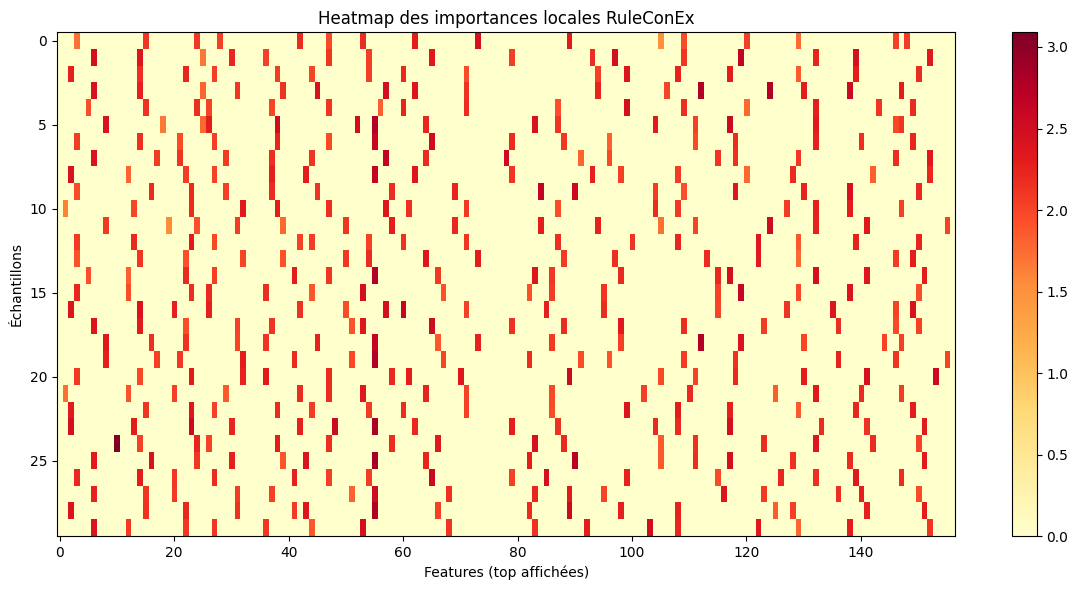

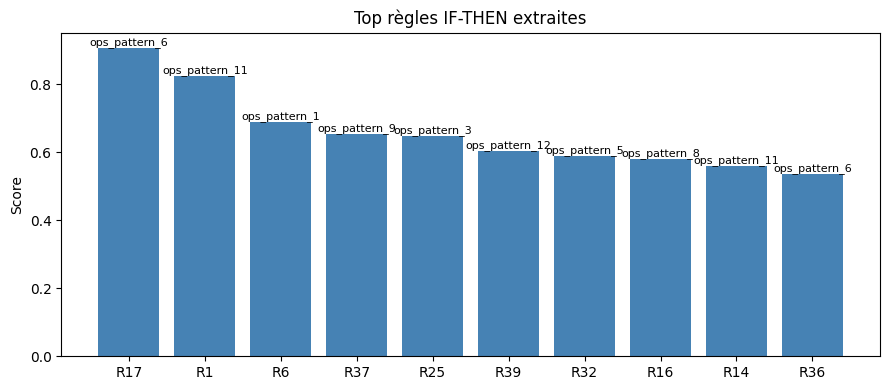

Règles IF-THEN extraites (HyperLogic)
R17 | IF oh_8=+1 AND oh_32=+1 AND oh_55=-1 AND oh_62=-1
     THEN ops_pattern_6  (confiance=0.906)

R01 | IF oh_118=-1 AND oh_15=+1 AND oh_39=-1 AND oh_29=+1
     THEN ops_pattern_11  (confiance=0.823)

R06 | IF oh_100=+1 AND oh_124=+1 AND oh_82=+1 AND oh_76=+1
     THEN ops_pattern_1  (confiance=0.689)

R37 | IF oh_97=-1 AND oh_75=-1 AND oh_22=-1 AND oh_149=-1
     THEN ops_pattern_9  (confiance=0.654)

R25 | IF oh_8=+1 AND oh_5=+1 AND oh_43=+1 AND oh_99=+1
     THEN ops_pattern_3  (confiance=0.648)

R39 | IF oh_83=+1 AND oh_21=+1 AND oh_26=+1 AND oh_138=+1
     THEN ops_pattern_12  (confiance=0.604)

R32 | IF oh_100=-1 AND oh_112=-1 AND oh_120=-1 AND oh_55=-1
     THEN ops_pattern_5  (confiance=0.588)

R16 | IF oh_54=-1 AND oh_99=-1 AND oh_20=-1 AND oh_34=-1
     THEN ops_pattern_8  (confiance=0.579)

R14 | IF oh_130=+1 AND oh_95=-1 AND oh_71=+1 AND oh_86=+1
     THEN ops_pattern_11  (confiance=0.559)

R36 | IF oh_146=-1 AND oh_112=+1 AND oh_106=

In [16]:
# Vue globale : heatmap importances + règles globales
fig_imp = plot_importance_heatmap(
    rc_model,
    explain_splits.x_test,
    explain_splits.y_test,
    explain_splits.feature_names,
    n_samples=30,
    device=rc_trainer.device,
    out_path=RESULTS_DIR / "ruleconex_importance_heatmap.png",
)
plt.show()

with torch.no_grad():
    _pack0 = rc_model.forward_pack(
        torch.tensor(explain_splits.x_test[:1], dtype=torch.float32, device=rc_trainer.device)
    )
global_rules = extract_rules_from_pack(
    _pack0,
    explain_splits.feature_names,
    explain_splits.class_names,
    rules_on_input=rc_model.rules_on_input,
    latent_dim=rc_model.latent_dim,
    max_rules=25,
)
fig_rules = plot_rules_bar(global_rules, out_path=RESULTS_DIR / "ruleconex_rules_bar.png")
plt.show()
print(format_rules_text(global_rules, max_rules=25))


In [17]:
def show_branch_contributions(model, x_np, class_names):
  """Logits par branche et poids de fusion."""
  device = next(model.parameters()).device
  x = torch.tensor(x_np, dtype=torch.float32, device=device).unsqueeze(0)
  with torch.no_grad():
    pack = model.forward_pack(x)
    probs = torch.softmax(pack.logits, dim=1)[0]
    pred = int(probs.argmax())
  wh, wr, wd = model.branch_weights()
  rows = []
  for name, logits_b in [
    ("HyConEx", pack.logits_hyconex),
    ("Règles", pack.logits_rules),
    ("Fusion", pack.logits),
  ]:
    pb = torch.softmax(logits_b, dim=1)[0]
    rows.append({
      "branche": name,
      "pred": class_names[int(pb.argmax())],
      "conf": float(pb[pred]),
    })
  if pack.logits_deep is not None and wd > 0:
    pd_ = torch.softmax(pack.logits_deep, dim=1)[0]
    rows.append({"branche": "Deep", "pred": class_names[int(pd_.argmax())], "conf": float(pd_[pred])})
  df_b = pd.DataFrame(rows)
  print(f"Poids fusion : HyConEx={wh:.3f} | Règles={wr:.3f} | Deep={wd:.3f}")
  print(f"Prédiction fusion : {class_names[pred]} ({probs[pred]:.4f})")
  display(df_b)
  # Top contributions HyConEx (features)
  imps = feature_importances_from_pack(pack, explain_splits.feature_names, class_idx=pred, top_k=12)
  df_imp = pd.DataFrame(imps, columns=["feature", "importance"])
  print("Top importances (contributions locales) :")
  display(df_imp)
  fig, ax = plt.subplots(figsize=(8, 4))
  ax.barh(df_imp["feature"], df_imp["importance"], color="steelblue")
  ax.invert_yaxis()
  ax.set_title("Contributions locales HyConEx")
  plt.tight_layout()
  plt.show()
  return pack, pred



######################################################################
Échantillon test #0 | vrai=ops_pattern_12
######################################################################
Poids fusion : HyConEx=0.429 | Règles=0.429 | Deep=0.143
Prédiction fusion : ops_pattern_12 (0.9948)


,branche,pred,conf
0,HyConEx,ops_pattern_12,0.999950
1,Règles,ops_pattern_12,0.957841
2,Fusion,ops_pattern_12,0.994752
3,Deep,ops_pattern_6,0.061830


Top importances (contributions locales) :


,feature,importance
0,oh_90,3.637200
1,oh_55,3.629952
2,oh_22,3.565880
3,oh_138,3.489685
4,oh_100,3.449324
5,oh_5,2.931481
6,oh_16,2.097964
7,oh_134,1.276119
8,oh_125,0.384071
9,oh_29,0.379028


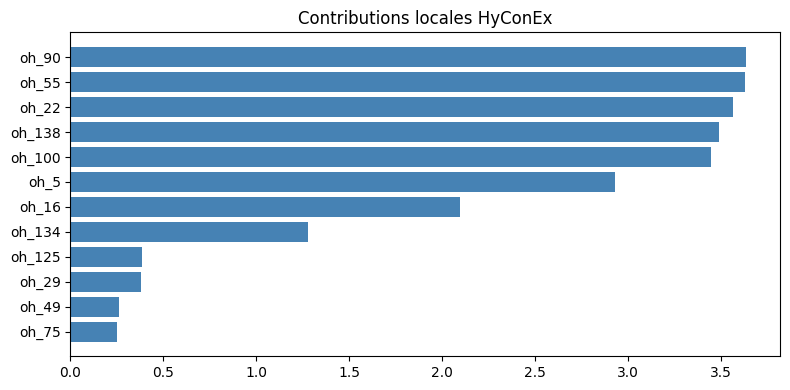

RuleConEx — Rapport d'explication
Prédiction : ops_pattern_12 (idx=12)
Probabilités :
  - ops_pattern_0: 0.0000
  - ops_pattern_1: 0.0000
  - ops_pattern_2: 0.0000
  - ops_pattern_3: 0.0000
  - ops_pattern_4: 0.0000
  - ops_pattern_5: 0.0000
  - ops_pattern_6: 0.0053
  - ops_pattern_7: 0.0000
  - ops_pattern_8: 0.0000
  - ops_pattern_9: 0.0000
  - ops_pattern_10: 0.0000
  - ops_pattern_11: 0.0000
  - ops_pattern_12: 0.9947
  - ops_pattern_13: 0.0000
  - ops_pattern_14: 0.0000
  - ops_pattern_15: 0.0000

Top importances locales (métadonnées) :
  - oh_90: 3.6372
  - oh_55: 3.6300
  - oh_22: 3.5659
  - oh_138: 3.4897
  - oh_100: 3.4493
  - oh_5: 2.9315
  - oh_16: 2.0980
  - oh_134: 1.2761
  - oh_125: 0.3841
  - oh_29: 0.3790
  - oh_49: 0.2600
  - oh_75: 0.2514

Règles IF-THEN extraites :
  IF oh_8=+1 AND oh_32=+1 AND oh_55=-1 AND oh_62=-1 THEN ops_pattern_6 (score=0.905)
  IF oh_118=-1 AND oh_15=+1 AND oh_39=-1 AND oh_29=+1 THEN ops_pattern_11 (score=0.823)
  IF oh_100=+1 AND oh_124=+1 AN

,rule_id,conditions,then,score
0,17,oh_8=+1 AND oh_32=+1 AND oh_55=-1 AND oh_62=-1,ops_pattern_6,0.9054
1,1,oh_118=-1 AND oh_15=+1 AND oh_39=-1 AND oh_29=+1,ops_pattern_11,0.8230
2,6,oh_100=+1 AND oh_124=+1 AND oh_82=+1 AND oh_76=+1,ops_pattern_1,0.6891
3,37,oh_97=-1 AND oh_75=-1 AND oh_22=-1 AND oh_149=-1,ops_pattern_9,0.6543
4,25,oh_8=+1 AND oh_5=+1 AND oh_43=+1 AND oh_99=+1,ops_pattern_3,0.6477
5,39,oh_83=+1 AND oh_21=+1 AND oh_26=+1 AND oh_138=+1,ops_pattern_12,0.6031
6,32,oh_100=-1 AND oh_112=-1 AND oh_120=-1 AND oh_1...,ops_pattern_5,0.5909
7,16,oh_54=-1 AND oh_99=-1 AND oh_20=-1 AND oh_34=-1,ops_pattern_8,0.5809
8,14,oh_130=+1 AND oh_95=-1 AND oh_71=+1 AND oh_86=+1,ops_pattern_11,0.5600
9,42,oh_8=-1 AND oh_61=+1 AND oh_133=-1 AND oh_79=-1,ops_pattern_1,0.5360


Contrefactuels (tableau) :


,cible,prob_cf,n_flips,modifications
0,ops_pattern_6,1.0000,7,"oh_16: actif->inactif, oh_49: actif->inactif, ..."
1,ops_pattern_3,1.0000,11,"oh_5: actif->inactif, oh_16: actif->inactif, o..."
2,ops_pattern_8,0.9998,12,"oh_5: actif->inactif, oh_16: actif->inactif, o..."



######################################################################
Échantillon test #1 | vrai=ops_pattern_1
######################################################################
Poids fusion : HyConEx=0.429 | Règles=0.429 | Deep=0.143
Prédiction fusion : ops_pattern_1 (1.0000)


,branche,pred,conf
0,HyConEx,ops_pattern_1,1.000000
1,Règles,ops_pattern_1,0.989118
2,Fusion,ops_pattern_1,1.000000
3,Deep,ops_pattern_7,0.103468


Top importances (contributions locales) :


,feature,importance
0,oh_130,3.001739
1,oh_39,2.984413
2,oh_79,2.459299
3,oh_95,1.868548
4,oh_62,1.763915
5,oh_151,1.303969
6,oh_55,1.240470
7,oh_45,1.238148
8,oh_111,0.988075
9,oh_140,0.649580


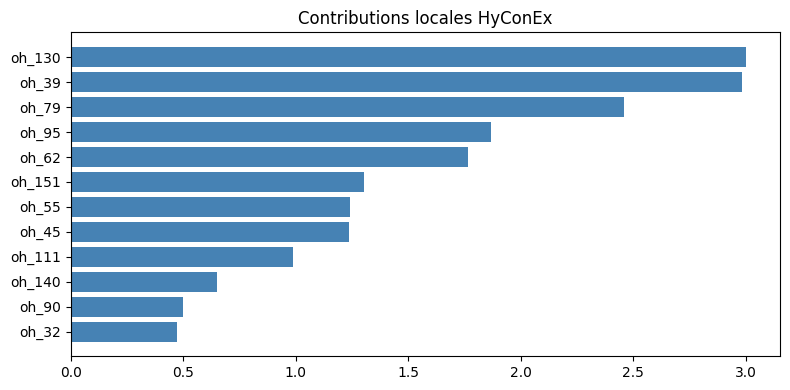

RuleConEx — Rapport d'explication
Prédiction : ops_pattern_1 (idx=1)
Probabilités :
  - ops_pattern_0: 0.0000
  - ops_pattern_1: 1.0000
  - ops_pattern_2: 0.0000
  - ops_pattern_3: 0.0000
  - ops_pattern_4: 0.0000
  - ops_pattern_5: 0.0000
  - ops_pattern_6: 0.0000
  - ops_pattern_7: 0.0000
  - ops_pattern_8: 0.0000
  - ops_pattern_9: 0.0000
  - ops_pattern_10: 0.0000
  - ops_pattern_11: 0.0000
  - ops_pattern_12: 0.0000
  - ops_pattern_13: 0.0000
  - ops_pattern_14: 0.0000
  - ops_pattern_15: 0.0000

Top importances locales (métadonnées) :
  - oh_130: 3.0017
  - oh_39: 2.9844
  - oh_79: 2.4593
  - oh_95: 1.8685
  - oh_62: 1.7639
  - oh_151: 1.3040
  - oh_55: 1.2405
  - oh_45: 1.2381
  - oh_111: 0.9881
  - oh_140: 0.6496
  - oh_90: 0.5013
  - oh_32: 0.4705

Règles IF-THEN extraites :
  IF oh_112=+1 AND oh_106=+1 AND oh_56=-1 AND oh_146=-1 THEN ops_pattern_6 (score=0.935)
  IF oh_82=+1 AND oh_87=+1 AND oh_63=+1 AND oh_37=-1 THEN ops_pattern_1 (score=0.852)
  IF oh_76=-1 AND oh_48=+1 AND

,rule_id,conditions,then,score
0,36,oh_112=+1 AND oh_106=+1 AND oh_56=-1 AND oh_14...,ops_pattern_6,0.9353
1,6,oh_82=+1 AND oh_87=+1 AND oh_63=+1 AND oh_37=-1,ops_pattern_1,0.8520
2,17,oh_76=-1 AND oh_48=+1 AND oh_123=-1 AND oh_8=+1,ops_pattern_6,0.8049
3,42,oh_113=+1 AND oh_72=+1 AND oh_37=+1 AND oh_118=-1,ops_pattern_6,0.7831
4,1,oh_125=+1 AND oh_118=-1 AND oh_95=+1 AND oh_15=+1,ops_pattern_1,0.7756
5,16,oh_64=+1 AND oh_4=+1 AND oh_33=+1 AND oh_23=+1,ops_pattern_8,0.7743
6,40,oh_95=-1 AND oh_2=-1 AND oh_49=-1 AND oh_66=-1,ops_pattern_15,0.7111
7,28,oh_87=-1 AND oh_12=+1 AND oh_98=-1 AND oh_142=-1,ops_pattern_0,0.6273
8,22,oh_148=+1 AND oh_107=+1 AND oh_80=-1 AND oh_10...,ops_pattern_14,0.6210
9,5,oh_36=-1 AND oh_0=-1 AND oh_125=-1 AND oh_95=-1,ops_pattern_1,0.6016


Contrefactuels (tableau) :


,cible,prob_cf,n_flips,modifications
0,ops_pattern_7,1.0000,9,"oh_6: actif->inactif, oh_16: actif->inactif, o..."
1,ops_pattern_12,1.0000,11,"oh_16: actif->inactif, oh_20: actif->inactif, ..."
2,ops_pattern_6,0.9999,12,"oh_16: actif->inactif, oh_20: actif->inactif, ..."



######################################################################
Échantillon test #2 | vrai=ops_pattern_5
######################################################################
Poids fusion : HyConEx=0.429 | Règles=0.429 | Deep=0.143
Prédiction fusion : ops_pattern_5 (1.0000)


,branche,pred,conf
0,HyConEx,ops_pattern_5,1.000000
1,Règles,ops_pattern_5,0.855418
2,Fusion,ops_pattern_5,1.000000
3,Deep,ops_pattern_5,0.651470


Top importances (contributions locales) :


,feature,importance
0,oh_16,3.773793
1,oh_3,3.496459
2,oh_90,3.357657
3,oh_44,3.306853
4,oh_61,2.809518
5,oh_23,1.162901
6,oh_36,0.905629
7,oh_104,0.869366
8,oh_141,0.628934
9,oh_148,0.429240


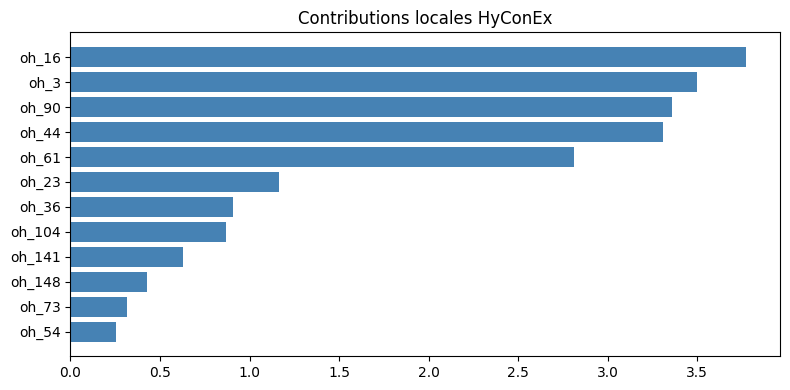

RuleConEx — Rapport d'explication
Prédiction : ops_pattern_5 (idx=5)
Probabilités :
  - ops_pattern_0: 0.0000
  - ops_pattern_1: 0.0000
  - ops_pattern_2: 0.0000
  - ops_pattern_3: 0.0000
  - ops_pattern_4: 0.0000
  - ops_pattern_5: 1.0000
  - ops_pattern_6: 0.0000
  - ops_pattern_7: 0.0000
  - ops_pattern_8: 0.0000
  - ops_pattern_9: 0.0000
  - ops_pattern_10: 0.0000
  - ops_pattern_11: 0.0000
  - ops_pattern_12: 0.0000
  - ops_pattern_13: 0.0000
  - ops_pattern_14: 0.0000
  - ops_pattern_15: 0.0000

Top importances locales (métadonnées) :
  - oh_16: 3.7738
  - oh_3: 3.4965
  - oh_90: 3.3577
  - oh_44: 3.3069
  - oh_61: 2.8095
  - oh_23: 1.1629
  - oh_36: 0.9056
  - oh_104: 0.8694
  - oh_141: 0.6289
  - oh_148: 0.4292
  - oh_73: 0.3138
  - oh_54: 0.2517

Règles IF-THEN extraites :
  IF oh_127=+1 AND oh_145=+1 AND oh_73=+1 AND oh_108=+1 THEN ops_pattern_6 (score=0.928)
  IF oh_87=-1 AND oh_129=+1 AND oh_38=-1 AND oh_144=-1 THEN ops_pattern_2 (score=0.877)
  IF oh_146=-1 AND oh_56=-1 AN

,rule_id,conditions,then,score
0,17,oh_127=+1 AND oh_145=+1 AND oh_73=+1 AND oh_10...,ops_pattern_6,0.9275
1,29,oh_87=-1 AND oh_129=+1 AND oh_38=-1 AND oh_144=-1,ops_pattern_2,0.8772
2,36,oh_146=-1 AND oh_56=-1 AND oh_36=-1 AND oh_106=+1,ops_pattern_6,0.8327
3,5,oh_36=-1 AND oh_0=-1 AND oh_125=-1 AND oh_95=-1,ops_pattern_1,0.6963
4,40,oh_107=-1 AND oh_62=-1 AND oh_33=-1 AND oh_88=-1,ops_pattern_6,0.6718
5,42,oh_8=-1 AND oh_61=+1 AND oh_133=-1 AND oh_79=-1,ops_pattern_6,0.6706
6,28,oh_12=+1 AND oh_15=-1 AND oh_70=+1 AND oh_87=-1,ops_pattern_0,0.6543
7,1,oh_20=+1 AND oh_125=+1 AND oh_95=+1 AND oh_98=-1,ops_pattern_1,0.6505
8,6,oh_76=+1 AND oh_100=+1 AND oh_69=-1 AND oh_124=+1,ops_pattern_1,0.5929
9,22,oh_153=-1 AND oh_148=+1 AND oh_80=-1 AND oh_14=-1,ops_pattern_14,0.5617


Contrefactuels (tableau) :


,cible,prob_cf,n_flips,modifications
0,ops_pattern_10,1.0,9,"oh_23: actif->inactif, oh_32: actif->inactif, ..."
1,ops_pattern_12,1.0,12,"oh_3: actif->inactif, oh_16: actif->inactif, o..."
2,ops_pattern_0,1.0,12,"oh_3: actif->inactif, oh_16: actif->inactif, o..."



Résumé explications :


,idx,true,pred,ok
0,0,ops_pattern_12,ops_pattern_12,True
1,1,ops_pattern_1,ops_pattern_1,True
2,2,ops_pattern_5,ops_pattern_5,True


In [18]:
explanation_rows = []

for idx in EXPLAIN_INDICES:
    if idx >= len(explain_splits.x_test):
        print(f"Index {idx} hors test (n={len(explain_splits.x_test)})")
        continue
    x_i = explain_splits.x_test[idx]
    y_i = int(explain_splits.y_test[idx])
    true_label = explain_splits.class_names[y_i]

    print("\n" + "#" * 70)
    print(f"Échantillon test #{idx} | vrai={true_label}")
    print("#" * 70)

    pack_i, pred_i = show_branch_contributions(rc_model, x_i, explain_splits.class_names)

    rep = explain_sample(
        rc_model,
        x_i,
        None,
        feature_names=explain_splits.feature_names,
        class_names=explain_splits.class_names,
        device=rc_trainer.device,
        top_k=12,
    )
    print(rep.text_report)

    # Table règles
    if rep.rules:
        df_rules = pd.DataFrame([
            {"rule_id": r["rule_id"], "conditions": " AND ".join(r["if"]), "then": r["then_class"], "score": r["score"]}
            for r in rep.rules[:15]
        ])
        print("Règles (tableau) :")
        display(df_rules.round(4))

    # Table contrefactuels
    if rep.counterfactuals:
        cf_rows = []
        for cf in rep.counterfactuals:
            flips = ", ".join(
                f"{f['feature']}: {f['from']}->{f['to']}" for f in cf.get("flipped_features", [])[:6]
            )
            cf_rows.append({
                "cible": cf["target_class"],
                "prob_cf": cf["cf_success_prob"],
                "n_flips": cf["n_flips"],
                "modifications": flips or "(aucun flip)",
            })
        print("Contrefactuels (tableau) :")
        display(pd.DataFrame(cf_rows).round(4))

    explanation_rows.append({
        "idx": idx,
        "true": true_label,
        "pred": rep.prediction_label,
        "ok": true_label == rep.prediction_label,
    })

summary_explain = pd.DataFrame(explanation_rows)
if not summary_explain.empty:
    print("\nRésumé explications :")
    display(summary_explain)
    summary_explain.to_csv(RESULTS_DIR / "ruleconex_explanations_summary.csv", index=False)


## Erreurs et runs ignorés

In [19]:
df_err = df[df["status"] == "error"]
df_skip = df[df["status"] == "skipped"]

if not df_err.empty:
    print("=== Erreurs ===")
    display(df_err[["dataset_id", "model_label", "error"]])
else:
    print("Aucune erreur.")

if not df_skip.empty:
    print("=== Ignorés (ex. TabResNet hors DLBAC) ===")
    display(df_skip[["dataset_id", "model_label", "reason"]])

Aucune erreur.


## Export CSV

In [20]:
csv_path = build_pivot_csv(RESULTS_DIR)
pivot_acc.to_csv(RESULTS_DIR / "pivot_accuracy.csv")
pivot_f1.to_csv(RESULTS_DIR / "pivot_f1.csv")
if "pivot_auc" in dir() and pivot_auc is not None:
    pivot_auc.to_csv(RESULTS_DIR / "pivot_auc.csv")
print("Fichiers exportés :")
for p in sorted(RESULTS_DIR.glob("*")):
    if p.is_file():
        print(" -", p.name)


Fichiers exportés :
 - heatmap_accuracy.png
 - heatmap_accuracy_f1.png
 - heatmap_auc.png
 - heatmap_cf_validity.png
 - heatmap_elapsed_sec.png
 - heatmap_f1_macro.png
 - metrics_pivot.csv
 - pivot_accuracy.csv
 - pivot_auc.csv
 - pivot_f1.csv
 - progress.json
 - ranking_accuracy.png
 - ranking_accuracy_by_source.csv
 - ranking_auc.png
 - ranking_auc_by_source.csv
 - ranking_cf_validity.png
 - ranking_cf_validity_by_source.csv
 - ranking_elapsed_sec.png
 - ranking_elapsed_sec_by_source.csv
 - ranking_f1_macro.png
 - ranking_f1_macro_by_source.csv
 - ranking_mean_accuracy.png
 - ranking_mean_rank.csv
 - ranking_mean_rank.png
 - ranking_ranks_matrix.png
 - rankings_all_metrics.csv
 - rankings_all_metrics.png
 - ruleconex_explanations_summary.csv
 - ruleconex_importance_heatmap.png
 - ruleconex_rules_bar.png
 - summary.json
 - wins_by_metric.csv
 - wins_by_metric.png
